# Production AOI Test — SankofaWatch

Pull HLS imagery from GEE for a custom AOI, preprocess it exactly as production does,
run tiled inference through the model, and visualize the predictions.

This mirrors the full production pipeline:
- `NASA/HLS/HLSS30/v002` — same GEE collection as production
- Fmask cloud masking → median composite → `.toFloat()`
- Bands: B2, B3, B4, B8, B11, B12 → BSI computed → model input: [B3, B4, B8, B11, B12, BSI]
- `nan_to_num` before preprocessing
- Per-tile p2–p98 percentile normalization (256×256, 128px overlap)

## 1. Imports

In [1]:
import ee
import torch
import segmentation_models_pytorch as smp
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
import requests
import tempfile
import os
import warnings
warnings.filterwarnings('ignore')

print('All packages imported.')

C:\Users\mcnob\Documents\Ashesi A\Cappy Cap\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All packages imported.


## 2. Initialize Earth Engine

In [2]:
# ee.Authenticate()   # ← uncomment and run once if not yet authenticated
ee.Initialize(project='coherent-ranger-486408-m8')
print('Earth Engine initialized.')

Earth Engine initialized.


## 3. Configuration

In [3]:
AOI_BBOX   = [-1.865, 6.102, -1.835, 6.132]
AOI_NAME   = 'Amansie_West_Manso'
START_DATE = '2023-01-01'
END_DATE   = '2024-12-31'
MODEL_PATH = 'geowatchai/models/best_precision_model_6band.pth'
THRESHOLD  = 0.5
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'AOI:    {AOI_NAME}  {AOI_BBOX}')
print(f'Dates:  {START_DATE} → {END_DATE}')
print(f'Model:  {MODEL_PATH}')
print(f'Device: {DEVICE}')

AOI:    Amansie_West_Manso  [-1.865, 6.102, -1.835, 6.132]
Dates:  2023-01-01 → 2024-12-31
Model:  geowatchai/models/best_precision_model_6band.pth
Device: cpu


## 4. GEE Helper Functions

In [4]:
def mask_hls_clouds(image):
    qa   = image.select('Fmask')
    mask = (qa.bitwiseAnd(1 << 1).eq(0)
              .And(qa.bitwiseAnd(1 << 2).eq(0))
              .And(qa.bitwiseAnd(1 << 3).eq(0)))
    return image.updateMask(mask)

def get_hls_composite(bbox, start_date, end_date):
    min_lon, min_lat, max_lon, max_lat = bbox
    geometry = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
    composite = (
        ee.ImageCollection('NASA/HLS/HLSS30/v002')
          .filterBounds(geometry)
          .filterDate(start_date, end_date)
          .map(mask_hls_clouds)
          .select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12'])
          .median()
          .clip(geometry)
          .toFloat()
          .reproject(crs=ee.Projection('EPSG:32630'), scale=30)
    )
    return composite, geometry

print('GEE helpers defined.')

GEE helpers defined.


## 5. Load Model

In [5]:
def load_model(model_path, device):
    model_path = Path(model_path)
    if not model_path.is_absolute():
        model_path = Path(os.getcwd()) / model_path
    if not model_path.exists():
        raise FileNotFoundError(f'Model not found: {model_path}')
    model = smp.FPN(encoder_name='resnet50', encoder_weights=None,
                    in_channels=6, classes=1, activation=None).to(device)
    import pathlib, platform
    _orig = pathlib.PosixPath
    if platform.system() == 'Windows':
        pathlib.PosixPath = pathlib.WindowsPath
    try:
        ckpt = torch.load(str(model_path), map_location=device, weights_only=False)
    finally:
        pathlib.PosixPath = _orig
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f'Model loaded: {model_path.name}')
    return model

device = torch.device(DEVICE)
model  = load_model(MODEL_PATH, device)

Model loaded: best_precision_model_6band.pth


## 6. Download Imagery from GEE

In [6]:
print(f'Building composite for {AOI_NAME}...')
composite, geometry = get_hls_composite(AOI_BBOX, START_DATE, END_DATE)

info       = composite.getInfo()
band_names = [b['id'] for b in info['bands']]
print(f'Bands in composite: {band_names}')

print('Downloading GeoTIFF from GEE...')
url = composite.getDownloadURL({
    'region': geometry, 'scale': 30, 'crs': 'EPSG:32630', 'format': 'GEO_TIFF'
})
response = requests.get(url, timeout=300)
if response.status_code != 200:
    raise RuntimeError(f'Download failed: HTTP {response.status_code}')
if len(response.content) < 1000:
    raise RuntimeError('Response too small — AOI may have no imagery in date range')

tif_path = Path(tempfile.mkdtemp()) / f'{AOI_NAME}.tif'
tif_path.write_bytes(response.content)
print(f'Saved: {tif_path}  ({len(response.content)/1024:.0f} KB)')

Building composite for Amansie_West_Manso...
Bands in composite: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
Saved: C:\Users\mcnob\AppData\Local\Temp\tmp6im0znbx\Amansie_West_Manso.tif  (199 KB)


## 7. True-Color Image — What Is GEE Actually Sampling?

Shows the **actual downloaded satellite image** as true-color RGB (B4=Red, B3=Green, B2=Blue).
Also prints the real-world bounding box of the downloaded GeoTIFF so you can verify it is the correct location.

CRS:       PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Pixel size: 30.0 m × 30.0 m
Image size: 111 × 112 px  =  3.3 km × 3.4 km
Extent (EPSG:32630): X [625560, 628920]   Y [674610, 677940]


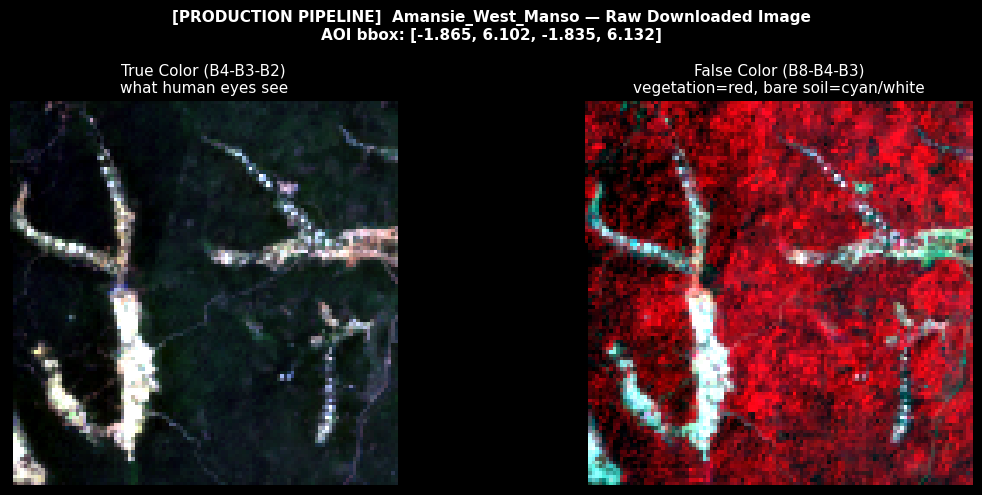

Saved: Amansie_West_Manso_true_color_production.png


In [7]:
with rasterio.open(tif_path) as src:
    raw  = src.read().astype(np.float32)   # (6, H, H): B2, B3, B4, B8, B11, B12
    tf   = src.transform
    crs  = src.crs
    h, w = src.height, src.width

# Print real-world extent so you can verify the location
min_x = tf.c
max_y = tf.f
max_x = tf.c + tf.a * w
min_y = tf.f + tf.e * h
print(f'CRS:       {crs}')
print(f'Pixel size: {tf.a:.1f} m × {abs(tf.e):.1f} m')
print(f'Image size: {h} × {w} px  =  {h*abs(tf.e)/1000:.1f} km × {w*tf.a/1000:.1f} km')
print(f'Extent (EPSG:32630): X [{min_x:.0f}, {max_x:.0f}]   Y [{min_y:.0f}, {max_y:.0f}]')

def stretch(band):
    valid = band[np.isfinite(band)]
    if len(valid) < 10:
        return np.full_like(band, 0.5)
    p2, p98 = np.percentile(valid, [2, 98])
    return np.clip((band - p2) / max(p98 - p2, 1e-8), 0, 1)

# True color: R=B4(idx2), G=B3(idx1), B=B2(idx0)
true_color = np.stack([stretch(raw[2]), stretch(raw[1]), stretch(raw[0])], axis=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(true_color)
axes[0].set_title('True Color (B4-B3-B2)\nwhat human eyes see', fontsize=11)
axes[0].axis('off')

# False color: R=B8(idx3), G=B4(idx2), B=B3(idx1) — vegetation=red, bare soil=cyan/white
false_color = np.stack([stretch(raw[3]), stretch(raw[2]), stretch(raw[1])], axis=2)
axes[1].imshow(false_color)
axes[1].set_title('False Color (B8-B4-B3)\nvegetation=red, bare soil=cyan/white', fontsize=11)
axes[1].axis('off')

fig.suptitle(f'[PRODUCTION PIPELINE]  {AOI_NAME} — Raw Downloaded Image\n'
             f'AOI bbox: {AOI_BBOX}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{AOI_NAME}_true_color_production.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {AOI_NAME}_true_color_production.png')

## 8. Preprocessing

In [8]:
def preprocess_geotiff(tif_path):
    with rasterio.open(tif_path) as src:
        data = src.read().astype(np.float32)
        meta = dict(crs=src.crs, transform=src.transform, width=src.width, height=src.height)
    finite = data[np.isfinite(data)]
    print(f'[Diag] Raw — min={finite.min():.4f}  max={finite.max():.4f}  mean={finite.mean():.4f}  shape={data.shape}')
    print(f'[Diag] Invalid pixels: {100*(~np.isfinite(data)).sum()/data.size:.1f}%')
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    B2, B3, B4, B8, B11, B12 = data[0], data[1], data[2], data[3], data[4], data[5]
    num   = (B11 + B4) - (B8 + B2)
    denom = np.where((B11 + B4) + (B8 + B2) == 0, 1e-8, (B11 + B4) + (B8 + B2))
    BSI   = np.clip(num / denom, -1, 1)
    tensor = np.stack([B3, B4, B8, B11, B12, BSI], axis=0).astype(np.float32)
    print(f'Tensor shape: {tensor.shape}  |  BSI range: [{BSI.min():.3f}, {BSI.max():.3f}]')
    return tensor, meta

tensor, meta = preprocess_geotiff(tif_path)
_, H, W = tensor.shape
print(f'Image size: {H} × {W} px  ({H*30:.0f} m × {W*30:.0f} m)')

[Diag] Raw — min=0.0087  max=0.3993  mean=0.1168  shape=(6, 111, 112)
[Diag] Invalid pixels: 0.6%
Tensor shape: (6, 111, 112)  |  BSI range: [-0.266, 0.208]
Image size: 111 × 112 px  (3330 m × 3360 m)


## 9. Tiled Inference

In [9]:
def normalize_tile(tile):
    out = np.zeros_like(tile, dtype=np.float32)
    for b in range(tile.shape[0]):
        band  = tile[b]
        valid = band[np.isfinite(band)]
        if len(valid) > 10:
            p2, p98 = np.percentile(valid, [2, 98])
            out[b]  = np.clip((band - p2) / (p98 - p2), 0, 1) if p98 > p2 else np.full_like(band, 0.5)
        else:
            out[b] = np.full_like(band, 0.5)
    return out

def make_weight_window(size):
    ramp = np.minimum(np.arange(1, size + 1), np.arange(size, 0, -1)).astype(np.float32)
    w = np.outer(ramp, ramp)
    return w / w.max()

def predict_single_tile(model, tile_norm, device):
    t = torch.from_numpy(tile_norm).float().unsqueeze(0).to(device)
    _, _, th, tw = t.shape
    ph = (32 - th % 32) % 32
    pw = (32 - tw % 32) % 32
    if ph or pw:
        import torch.nn.functional as F
        t = F.pad(t, (0, pw, 0, ph), mode='reflect')
    with torch.no_grad():
        prob = torch.sigmoid(model(t)).squeeze().cpu().numpy()
    if prob.ndim == 3:
        prob = prob.squeeze(0)
    return prob[:th, :tw]

def predict_tiled(model, tensor, device, tile_size=256, overlap=128):
    _, H, W  = tensor.shape
    stride   = tile_size - overlap
    output   = np.zeros((H, W), dtype=np.float32)
    weights  = np.zeros((H, W), dtype=np.float32)
    ww       = make_weight_window(tile_size)
    def tile_starts(dim):
        if dim <= tile_size: return [0]
        starts = list(range(0, dim - tile_size, stride))
        if not starts or starts[-1] < dim - tile_size: starts.append(dim - tile_size)
        return starts
    rows, cols = tile_starts(H), tile_starts(W)
    print(f'Grid: {len(rows)}×{len(cols)} = {len(rows)*len(cols)} tiles')
    for r0 in rows:
        for c0 in cols:
            r1, c1 = min(r0 + tile_size, H), min(c0 + tile_size, W)
            th, tw = r1 - r0, c1 - c0
            tile   = tensor[:, r0:r1, c0:c1].copy()
            if th < tile_size or tw < tile_size:
                tile = np.pad(tile, ((0,0),(0,tile_size-th),(0,tile_size-tw)), mode='reflect')
            prob = predict_single_tile(model, normalize_tile(tile), device)[:th, :tw]
            w    = ww[:th, :tw]
            output [r0:r1, c0:c1] += prob * w
            weights[r0:r1, c0:c1] += w
    stitched = output / np.where(weights > 0, weights, 1.0)
    print(f'Probability range: [{stitched.min():.3f}, {stitched.max():.3f}]')
    return stitched

print('Running tiled inference...')
prob_map  = predict_tiled(model, tensor, device)
pred_mask = (prob_map >= THRESHOLD).astype(np.uint8)
mining_pixels = pred_mask.sum()
mining_ha     = mining_pixels * 30 * 30 / 10_000
print(f'\nMining detected: {mining_pixels} px = {mining_ha:.2f} ha  ({100*mining_pixels/pred_mask.size:.1f}% of AOI)')
print(f'Max probability: {prob_map.max():.3f}')

Running tiled inference...
Grid: 1×1 = 1 tiles
Probability range: [0.000, 1.000]

Mining detected: 728 px = 65.52 ha  (5.9% of AOI)
Max probability: 1.000


## 10. Visualize Results

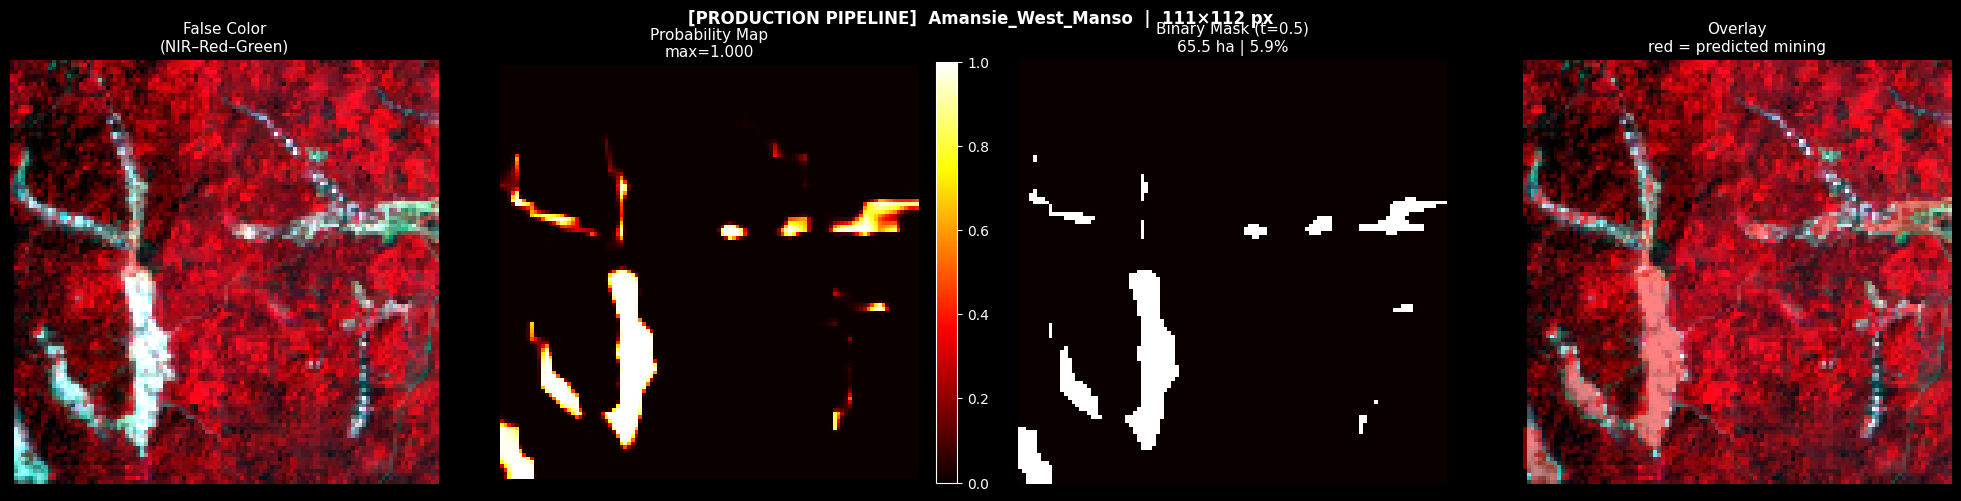

In [10]:
def make_false_color(tensor):
    rgb = np.zeros((*tensor.shape[1:], 3), dtype=np.float32)
    for dst, src_idx in enumerate([2, 1, 0]):
        band  = tensor[src_idx]
        valid = band[np.isfinite(band)]
        if len(valid) > 10:
            p2, p98 = np.percentile(valid, [2, 98])
            rgb[:, :, dst] = np.clip((band - p2) / max(p98 - p2, 1e-8), 0, 1)
        else:
            rgb[:, :, dst] = 0.5
    return rgb

rgb = make_false_color(tensor)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(rgb);  axes[0].set_title('False Color\n(NIR–Red–Green)', fontsize=11);  axes[0].axis('off')
im = axes[1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
axes[1].set_title(f'Probability Map\nmax={prob_map.max():.3f}', fontsize=11);  axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[2].imshow(pred_mask, cmap='hot', vmin=0, vmax=1)
axes[2].set_title(f'Binary Mask (t={THRESHOLD})\n{mining_ha:.1f} ha | {100*mining_pixels/pred_mask.size:.1f}%', fontsize=11)
axes[2].axis('off')
axes[3].imshow(rgb)
overlay = np.zeros((*pred_mask.shape, 4), dtype=np.float32)
overlay[pred_mask == 1] = [1, 0, 0, 0.5]
axes[3].imshow(overlay);  axes[3].set_title('Overlay\nred = predicted mining', fontsize=11);  axes[3].axis('off')
fig.suptitle(f'[PRODUCTION PIPELINE]  {AOI_NAME}  |  {H}×{W} px', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{AOI_NAME}_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Per-Band Inspection

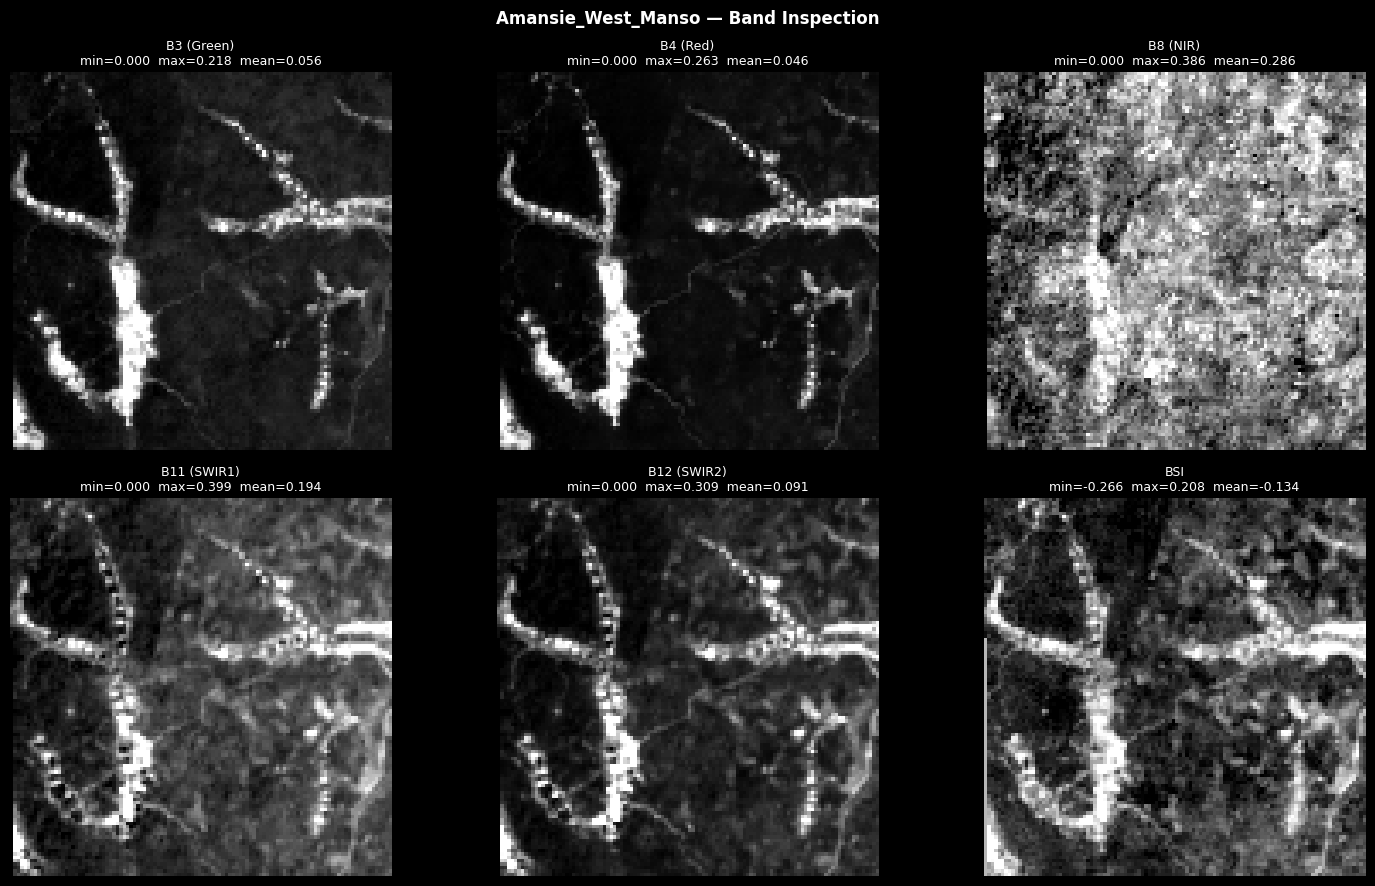

In [11]:
BAND_NAMES = ['B3 (Green)', 'B4 (Red)', 'B8 (NIR)', 'B11 (SWIR1)', 'B12 (SWIR2)', 'BSI']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for idx, ax in enumerate(axes.flat):
    band  = tensor[idx]
    valid = band[np.isfinite(band)]
    p2, p98 = np.percentile(valid, [2, 98]) if len(valid) > 10 else (0, 1)
    disp = np.clip((band - p2) / max(p98 - p2, 1e-8), 0, 1)
    ax.imshow(disp, cmap='gray')
    ax.set_title(f'{BAND_NAMES[idx]}\nmin={valid.min():.3f}  max={valid.max():.3f}  mean={valid.mean():.3f}', fontsize=9)
    ax.axis('off')
fig.suptitle(f'{AOI_NAME} — Band Inspection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Run All Test Locations


Amansie_West_Manso
[Diag] Raw — min=0.0087  max=0.3993  mean=0.1168  shape=(6, 111, 112)
[Diag] Invalid pixels: 0.6%
Tensor shape: (6, 111, 112)  |  BSI range: [-0.266, 0.208]
Grid: 1×1 = 1 tiles
Probability range: [0.000, 1.000]
  MINING           65.5 ha  max_p=1.000  ✓


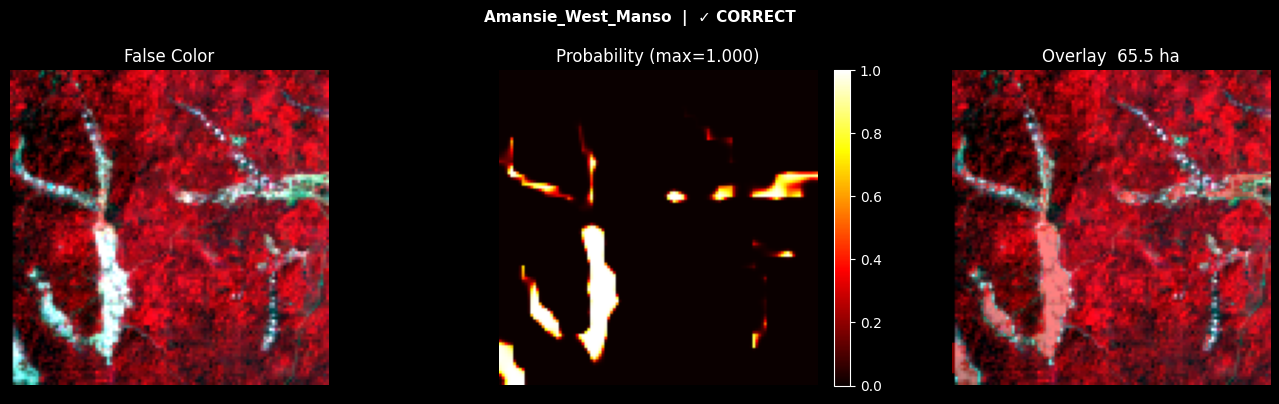


Dunkwa_Offin_River
[Diag] Raw — min=0.0051  max=0.4295  mean=0.1363  shape=(6, 112, 112)
[Diag] Invalid pixels: 0.4%
Tensor shape: (6, 112, 112)  |  BSI range: [-0.286, 0.304]
Grid: 1×1 = 1 tiles
Probability range: [0.000, 0.000]
  NO MINING        0.0 ha  max_p=0.000  ✗


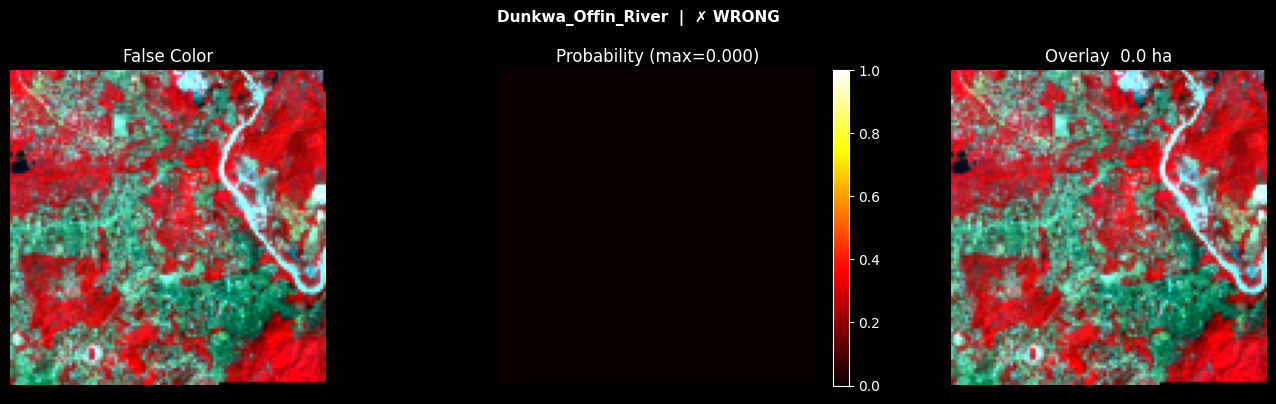


Goldfields_Tarkwa
[Diag] Raw — min=0.0198  max=0.3791  mean=0.1447  shape=(6, 112, 112)
[Diag] Invalid pixels: 1.0%
Tensor shape: (6, 112, 112)  |  BSI range: [-0.214, 0.304]
Grid: 1×1 = 1 tiles
Probability range: [0.000, 0.000]
  NO MINING        0.0 ha  max_p=0.000  ✗


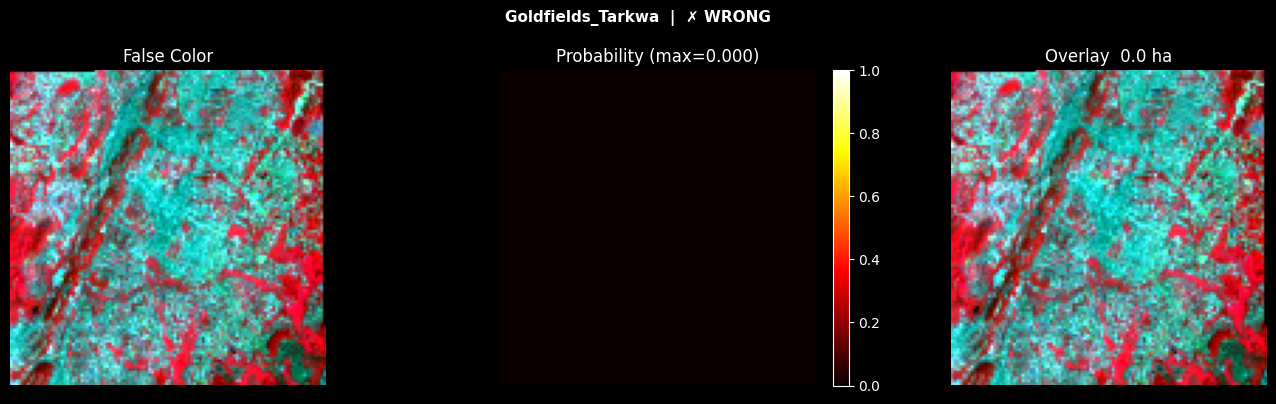


Wassa_Amenfi_Pra
[Diag] Raw — min=0.0107  max=0.3724  mean=0.1201  shape=(6, 112, 112)
[Diag] Invalid pixels: 1.7%
Tensor shape: (6, 112, 112)  |  BSI range: [-0.311, 0.166]
Grid: 1×1 = 1 tiles
Probability range: [0.000, 1.000]
  MINING           37.2 ha  max_p=1.000  ✓


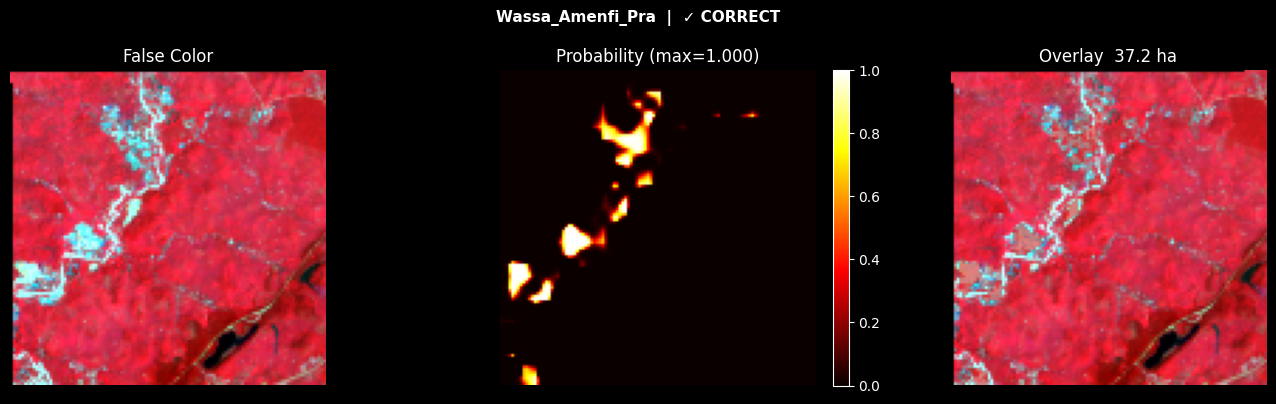


Atewa_Forest_Reserve
[Diag] Raw — min=0.0155  max=0.4086  mean=0.1074  shape=(6, 224, 224)
[Diag] Invalid pixels: 1.5%
Tensor shape: (6, 224, 224)  |  BSI range: [-0.322, 0.256]
Grid: 1×1 = 1 tiles
Probability range: [0.000, 0.000]
  NO MINING        0.0 ha  max_p=0.000  ✓


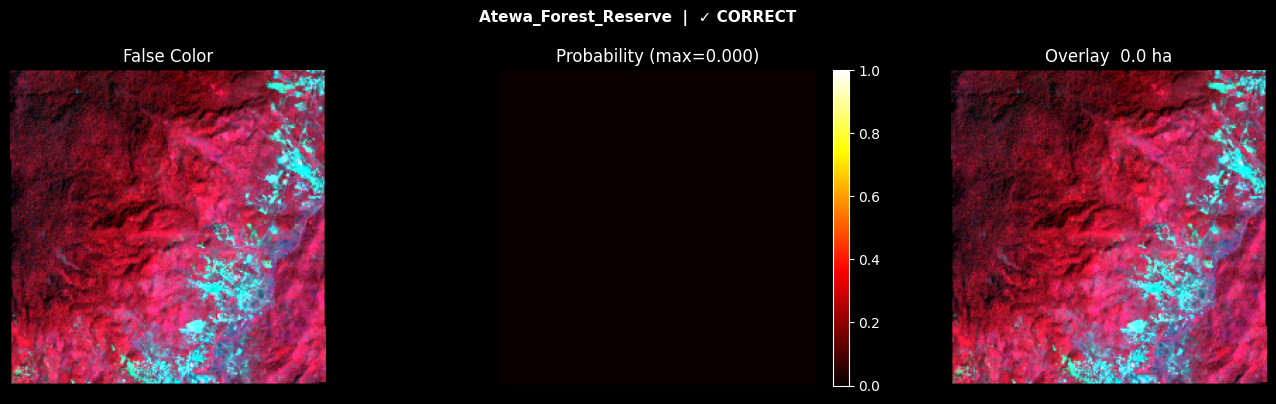


SUMMARY: 3/5 correct
  ✓  Amansie_West_Manso                     65.5 ha  max_p=1.000
  ✗  Dunkwa_Offin_River                      0.0 ha  max_p=0.000
  ✗  Goldfields_Tarkwa                       0.0 ha  max_p=0.000
  ✓  Wassa_Amenfi_Pra                       37.2 ha  max_p=1.000
  ✓  Atewa_Forest_Reserve                    0.0 ha  max_p=0.000


In [12]:
TEST_LOCATIONS = [
    {'name': 'Amansie_West_Manso',   'bbox': [-1.865, 6.102, -1.835, 6.132], 'expected': 'mining'},
    {'name': 'Dunkwa_Offin_River',   'bbox': [-1.798, 5.952, -1.768, 5.982], 'expected': 'mining'},
    {'name': 'Goldfields_Tarkwa',    'bbox': [-2.006, 5.281, -1.976, 5.311], 'expected': 'mining'},
    {'name': 'Wassa_Amenfi_Pra',     'bbox': [-2.098, 5.502, -2.068, 5.532], 'expected': 'mining'},
    {'name': 'Atewa_Forest_Reserve', 'bbox': [-0.580, 6.175, -0.520, 6.235], 'expected': 'no_mining'},
]
results = []
for loc in TEST_LOCATIONS:
    print(f"\n{'='*60}\n{loc['name']}")
    try:
        comp, geom = get_hls_composite(loc['bbox'], START_DATE, END_DATE)
        url  = comp.getDownloadURL({'region': geom, 'scale': 30, 'crs': 'EPSG:32630', 'format': 'GEO_TIFF'})
        resp = requests.get(url, timeout=300)
        if resp.status_code != 200 or len(resp.content) < 1000:
            print('  Download failed'); continue
        tmp = Path(tempfile.mkdtemp()) / f"{loc['name']}.tif"
        tmp.write_bytes(resp.content)
        t, _ = preprocess_geotiff(tmp)
        prob  = predict_tiled(model, t, device)
        mask  = (prob >= THRESHOLD).astype(np.uint8)
        mining_ha = mask.sum() * 30 * 30 / 10_000
        max_prob  = prob.max()
        correct   = (loc['expected'] == 'mining') == (mask.sum() > 0)
        print(f"  {'MINING' if mask.sum()>0 else 'NO MINING':15s}  {mining_ha:.1f} ha  max_p={max_prob:.3f}  {'✓' if correct else '✗'}")
        results.append({'name': loc['name'], 'expected': loc['expected'],
                        'mining_ha': mining_ha, 'max_prob': max_prob, 'correct': correct})
        rgb_loc = make_false_color(t)
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(rgb_loc);  axes[0].set_title('False Color');  axes[0].axis('off')
        im2 = axes[1].imshow(prob, cmap='hot', vmin=0, vmax=1)
        axes[1].set_title(f'Probability (max={max_prob:.3f})');  axes[1].axis('off')
        plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
        axes[2].imshow(rgb_loc)
        ov = np.zeros((*mask.shape, 4), dtype=np.float32)
        ov[mask==1] = [1, 0, 0, 0.5]
        axes[2].imshow(ov);  axes[2].set_title(f'Overlay  {mining_ha:.1f} ha');  axes[2].axis('off')
        fig.suptitle(f"{loc['name']}  |  {'✓ CORRECT' if correct else '✗ WRONG'}", fontsize=11, fontweight='bold')
        plt.tight_layout();  plt.show();  plt.close()
        tmp.unlink(missing_ok=True)
    except Exception as e:
        print(f'  Error: {type(e).__name__}: {e}')
if results:
    n = sum(r['correct'] for r in results)
    print(f"\n{'='*60}\nSUMMARY: {n}/{len(results)} correct")
    for r in results:
        print(f"  {'✓' if r['correct'] else '✗'}  {r['name']:35s}  {r['mining_ha']:6.1f} ha  max_p={r['max_prob']:.3f}")